In [87]:
# Uncomment if needed

!pip install -q xgboost lightgbm catboost joblib

In [88]:
import warnings
warnings.filterwarnings("ignore")

import os
import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from lightgbm import LGBMClassifier

from catboost import CatBoostClassifier

In [89]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [90]:
PROJECT_DIR="/content/drive/MyDrive/Ghana_Dropout_Project"

MODEL_DIR=f"{PROJECT_DIR}/models"

RESULT_DIR=f"{PROJECT_DIR}/results"

os.makedirs(MODEL_DIR,exist_ok=True)

os.makedirs(RESULT_DIR,exist_ok=True)

df=pd.read_csv(f"{PROJECT_DIR}/cleaned_data.csv")

print(df.shape)

df.head()

(1000, 41)


,school_code,geographic_zone,school_type,data_source,gender,age_at_start_of_academic_year,class_level,grade_repetition_count,term_1_attendance,term_2_attendance,...,school_enjoyment,missed_school_for_choreswork,missed_school_due_to_illness,barriers_to_regular_attendance,family_income_level,parent_attends_school_events,behaviour_warnings_punishments,class_participation,extracurricular_activities,dropout_label
0,KNU_JHS,Peri-urban,Public,Questionnaire,Male,10.0,JHS1,0,85.0,82.0,...,3.0,No,"Yes, more than once",Nothing-come regularly,Medium,Sometimes,Never,5.0,1 activity,0
1,KNU_JHS,Peri-urban,Public,Questionnaire,Male,11.0,JHS1,0,87.0,79.0,...,3.0,No,"Yes, more than once",Nothing-come regularly,Medium,Rarely,Once,2.0,2 activities,0
2,KNU_JHS,Peri-urban,Public,Questionnaire,Male,10.0,JHS1,0,70.0,79.0,...,1.0,Yes,"Yes, more than once",Health problems,Medium,Sometimes,Never,5.0,2 activities,0
3,KNU_JHS,Peri-urban,Public,Questionnaire,Female,12.0,JHS1,0,80.0,83.0,...,4.0,No,"Yes, once",Nothing-come regularly,High,Often,Never,4.0,2 activities,0
4,KNU_JHS,Peri-urban,Public,Questionnaire,Female,10.0,JHS1,0,77.0,80.0,...,3.0,No,"Yes, more than once",Nothing-come regularly,High,Sometimes,Never,4.0,1 activity,0


In [91]:
TARGET="dropout_label"

X=df.drop(columns=[TARGET])

y=df[TARGET]

print(y.value_counts())

dropout_label
0    908
1     92
Name: count, dtype: int64


In [92]:
numeric_features=X.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features=X.select_dtypes(
    exclude=np.number
).columns.tolist()

print("Numeric:",len(numeric_features))

print("Categorical:",len(categorical_features))

Numeric: 16
Categorical: 24


In [94]:
X_train,X_test,y_train,y_test=train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y
)

In [95]:
print("Training")

print(y_train.value_counts())

print()

print("Testing")

print(y_test.value_counts())

Training
dropout_label
0    726
1     74
Name: count, dtype: int64

Testing
dropout_label
0    182
1     18
Name: count, dtype: int64


In [96]:
train_df=X_train.copy()

train_df[TARGET]=y_train.values

test_df=X_test.copy()

test_df[TARGET]=y_test.values

train_df.to_csv(
    f"{PROJECT_DIR}/train_real.csv",
    index=False
)

test_df.to_csv(
    f"{PROJECT_DIR}/test_real.csv",
    index=False
)

print("Train and Test datasets saved.")

Train and Test datasets saved.


In [98]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [99]:
models = {

    "Logistic Regression": LogisticRegression(
        random_state=42,
        max_iter=1000,
        class_weight="balanced"
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42,
        n_estimators=200,
        class_weight="balanced"
    ),

    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        use_label_encoder=False
    ),

    "LightGBM": LGBMClassifier(
        random_state=42,
        verbosity=-1
    ),

    "CatBoost": CatBoostClassifier(
        random_state=42,
        verbose=0
    )

}

In [100]:
def evaluate_model(name, model):

    # Build preprocessing + model pipeline
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])

    # Train
    pipeline.fit(X_train, y_train)

    # Predictions
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    # Metrics
    results = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, y_prob),
        "PR_AUC": average_precision_score(y_test, y_prob)
    }

    return pipeline, results

In [101]:
all_results = []

trained_models = {}

for name, model in models.items():

    print("=" * 60)
    print(f"Training {name}")
    print("=" * 60)

    pipeline, results = evaluate_model(name, model)

    trained_models[name] = pipeline

    all_results.append(results)

Training Logistic Regression
Training Decision Tree
Training Random Forest
Training XGBoost
Training LightGBM
Training CatBoost


In [102]:
results_df = pd.DataFrame(all_results)

results_df = results_df.sort_values(
    by="F1",
    ascending=False
)

results_df.reset_index(drop=True, inplace=True)

results_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Decision Tree,0.995,1.000000,0.944444,0.971429,0.972222,0.949444
1,Random Forest,0.995,1.000000,0.944444,0.971429,0.999084,0.992063
2,LightGBM,0.995,1.000000,0.944444,0.971429,0.996032,0.976703
3,XGBoost,0.995,1.000000,0.944444,0.971429,0.987485,0.961394
4,CatBoost,0.995,1.000000,0.944444,0.971429,0.997558,0.982906
5,Logistic Regression,0.985,0.894737,0.944444,0.918919,0.987485,0.961394


In [103]:
results_df.to_csv(

    f"{RESULT_DIR}/baseline_results.csv",

    index=False

)

print("Results saved.")

Results saved.


In [104]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])

    scores = cross_validate(

        pipeline,

        X,

        y,

        cv=cv,

        scoring=[
            "accuracy",
            "precision",
            "recall",
            "f1",
            "roc_auc"
        ],

        n_jobs=-1

    )

    cv_results.append({

        "Model": name,

        "Accuracy": scores["test_accuracy"].mean(),

        "Precision": scores["test_precision"].mean(),

        "Recall": scores["test_recall"].mean(),

        "F1": scores["test_f1"].mean(),

        "ROC_AUC": scores["test_roc_auc"].mean()

    })

cv_df = pd.DataFrame(cv_results)

cv_df.sort_values("F1", ascending=False)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
5,CatBoost,0.992,0.977709,0.935088,0.955505,0.990971
4,LightGBM,0.991,0.969474,0.935088,0.950620,0.980500
3,XGBoost,0.989,0.968235,0.913450,0.938901,0.984278
2,Random Forest,0.989,1.000000,0.880702,0.936085,0.996908
0,Logistic Regression,0.987,0.916257,0.946199,0.930299,0.975017
1,Decision Tree,0.985,0.922222,0.924561,0.920391,0.957876


In [105]:
cv_df.to_csv(
    f"{RESULT_DIR}/baseline_cv_results.csv",
    index=False
)

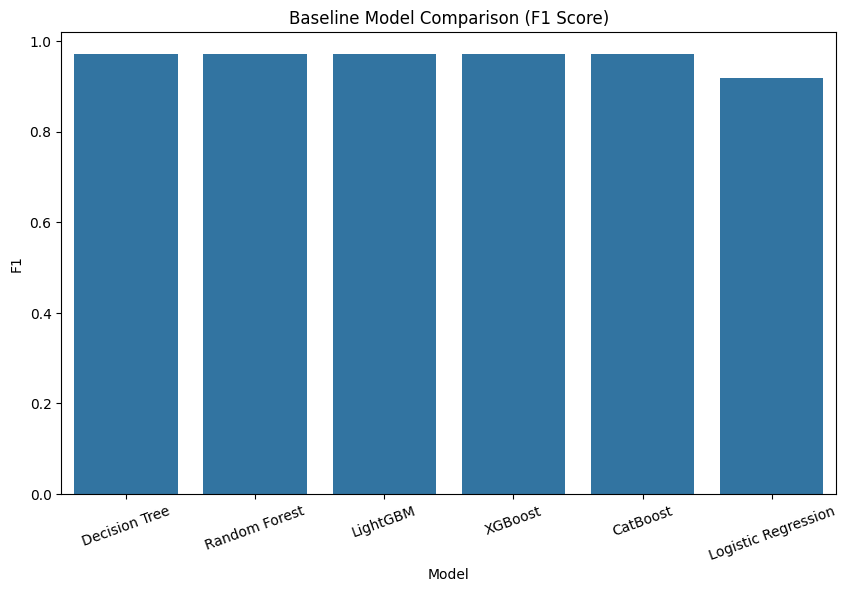

In [106]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=results_df,
    x="Model",
    y="F1"
)

plt.xticks(rotation=20)

plt.title("Baseline Model Comparison (F1 Score)")

plt.show()

In [107]:
best_model_name = results_df.iloc[0]["Model"]

best_pipeline = trained_models[best_model_name]

joblib.dump(

    best_pipeline,

    f"{MODEL_DIR}/best_baseline_model.pkl"

)

print(f"Best baseline model: {best_model_name}")

Best baseline model: Decision Tree


In [108]:
best_model_name = "CatBoost"

In [109]:
best_model_name = results_df.iloc[0]["Model"]